# Q11.
```{admonition}
:class: note
This question uses the `Caravan` data set.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, precision_score, make_scorer, recall_score
from sklearn.model_selection import train_test_split, FixedThresholdClassifier, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
caravan = pd.read_csv('../../../ALL CSV FILES - 2nd Edition/Caravan.csv')

In [5]:
caravan.describe()

,MOSTYPE,MAANTHUI,MGEMOMV,MGEMLEEF,MOSHOOFD,MGODRK,MGODPR,MGODOV,MGODGE,MRELGE,...,ALEVEN,APERSONG,AGEZONG,AWAOREG,ABRAND,AZEILPL,APLEZIER,AFIETS,AINBOED,ABYSTAND
count,5822.000000,5822.000000,5822.000000,5822.000000,5822.000000,5822.000000,5822.000000,5822.000000,5822.000000,5822.000000,...,5822.000000,5822.000000,5822.000000,5822.000000,5822.000000,5822.000000,5822.000000,5822.000000,5822.000000,5822.000000
mean,24.253349,1.110615,2.678805,2.991240,5.773617,0.696496,4.626932,1.069907,3.258502,6.183442,...,0.076606,0.005325,0.006527,0.004638,0.570079,0.000515,0.006012,0.031776,0.007901,0.014256
std,12.846706,0.405842,0.789835,0.814589,2.856760,1.003234,1.715843,1.017503,1.597647,1.909482,...,0.377569,0.072782,0.080532,0.077403,0.562058,0.022696,0.081632,0.210986,0.090463,0.119996
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10.000000,1.000000,2.000000,2.000000,3.000000,0.000000,4.000000,0.000000,2.000000,5.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,30.000000,1.000000,3.000000,3.000000,7.000000,0.000000,5.000000,1.000000,3.000000,6.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,35.000000,1.000000,3.000000,3.000000,8.000000,1.000000,6.000000,2.000000,4.000000,7.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,41.000000,10.000000,5.000000,6.000000,10.000000,9.000000,9.000000,5.000000,9.000000,9.000000,...,8.000000,1.000000,1.000000,2.000000,7.000000,1.000000,2.000000,3.000000,2.000000,2.000000


In [6]:
caravan.sample(3)

,MOSTYPE,MAANTHUI,MGEMOMV,MGEMLEEF,MOSHOOFD,MGODRK,MGODPR,MGODOV,MGODGE,MRELGE,...,APERSONG,AGEZONG,AWAOREG,ABRAND,AZEILPL,APLEZIER,AFIETS,AINBOED,ABYSTAND,Purchase
3257,41,1,3,3,10,0,5,0,4,7,...,0,0,0,1,0,0,0,0,0,No
4789,37,1,2,4,8,0,5,1,4,6,...,0,0,0,1,0,0,0,0,0,Yes
2661,4,2,2,4,1,1,4,1,4,4,...,0,0,0,1,0,1,0,0,0,No


## (a)
```{admonition}
:class: note
Create a training set consisting of the first $1\, 000$ observations, and a test set consisting of the remaining observation.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(caravan.drop(columns='Purchase'),caravan['Purchase'],random_state=1728,train_size=1000,shuffle=True,stratify=caravan['Purchase'])

## (b)
```{admonition}
:class: note
Fit a boosting model to the training set with `Purchase` as the response and the other variables as predictors. Use $1,000$ trees, and a shrinkage value of $0.01$. Which predictors appear to be the most important?

In [8]:
gbc = GradientBoostingClassifier(learning_rate=0.01,n_estimators=1000)
gbc.fit(X_train,y_train)

,loss,'log_loss'
,learning_rate,0.01
,n_estimators,1000
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [9]:
feat_importance = pd.DataFrame({'importance':gbc.feature_importances_},index=gbc.feature_names_in_)
feat_importance.sort_values(by='importance',ascending=False)[:10]

,importance
PPERSAUT,0.066494
APLEZIER,0.044032
PWAOREG,0.040667
MINK4575,0.037938
MOSTYPE,0.037116
MBERMIDD,0.036317
MBERARBG,0.031809
MBERARBO,0.031077
MSKA,0.031015
MFGEKIND,0.030442


## (c)
```{admonition}
:class: note
Use the boosting model to predict the response on the test data. Predict that a person will make a purchase if the estimated probability of purchase is greater than $20\%$. Form a confusion matrix. What fraction of the people predicted to make a purchase do in fact make one? How does this compare with the results obtained from applying KNN or logistic regression to this data set?

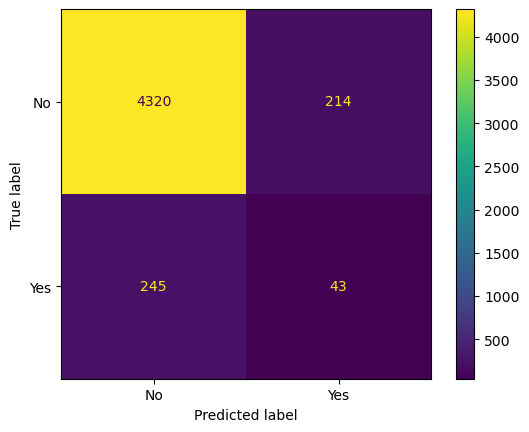

In [10]:
y_test_pred = FixedThresholdClassifier(gbc,threshold=0.2).predict(X_test)
gcb_precision = precision_score(y_test,y_test_pred,pos_label='Yes')
gcb_recall = recall_score(y_test,y_test_pred,pos_label='Yes')
confusion_matrix(y_test,y_test_pred)
CD_disp = ConfusionMatrixDisplay(confusion_matrix(y_test,y_test_pred),display_labels=gbc.classes_)
CD_disp.plot()
plt.show()

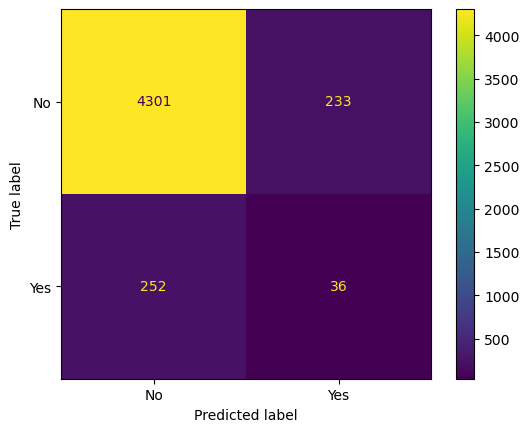

In [11]:
cv = StratifiedKFold()
knnst = KNeighborsClassifier()
def prec_threshold(y_true,y_proba,thresh=0.2):
    y_pred = y_proba[:,1]>= thresh
    return precision_score(y_true, y_pred)
precision_0 = make_scorer(prec_threshold,needs_proba=True,pos_label='Yes')
knnst_grid = GridSearchCV(knnst,{'n_neighbors':np.arange(1,20,2)},scoring=precision_0,n_jobs=-1,error_score=0,cv=cv)
knnst_grid.fit(X_train,y_train)

y_test_pred_knnst = FixedThresholdClassifier(knnst_grid,threshold=0.2).predict(X_test)
nst_neighb = knnst_grid.best_params_['n_neighbors']
knnst_precision = precision_score(y_test,y_test_pred_knnst,pos_label='Yes')
knnst_recall = recall_score(y_test,y_test_pred_knnst,pos_label='Yes')

CD_disp_knnst = ConfusionMatrixDisplay(confusion_matrix(y_test,y_test_pred_knnst),display_labels=knnst_grid.classes_)
CD_disp_knnst.plot()
plt.show()

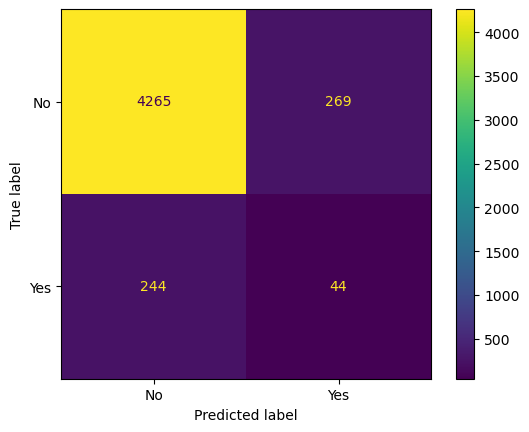

In [12]:
knn = KNeighborsClassifier()
knn_grid = GridSearchCV(knn,{'n_neighbors':np.arange(1,20,2)},scoring='accuracy',n_jobs=-1,error_score=0,cv=cv)
knn_grid.fit(X_train,y_train)
y_test_pred_knn = FixedThresholdClassifier(knn_grid,threshold=0.2).predict(X_test)
n_neighb = knn_grid.best_params_['n_neighbors']
knn_precision = precision_score(y_test,y_test_pred_knn,pos_label='Yes')
knn_recall = recall_score(y_test,y_test_pred_knn,pos_label='Yes')

CD_disp_knn = ConfusionMatrixDisplay(confusion_matrix(y_test,y_test_pred_knn),display_labels=knnst_grid.classes_)
CD_disp_knn.plot()
plt.show()

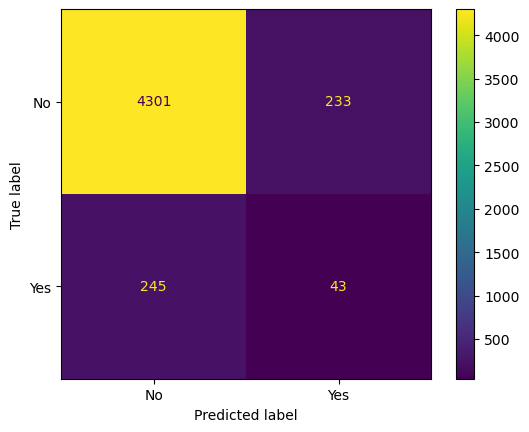

In [13]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train,y_train)
y_test_pred_logreg = FixedThresholdClassifier(logreg,threshold=0.2).predict(X_test)
logreg_precision = precision_score(y_test,y_test_pred_logreg,pos_label='Yes')
logreg_recall = recall_score(y_test,y_test_pred_logreg,pos_label='Yes')

CD_disp_logreg = ConfusionMatrixDisplay(confusion_matrix(y_test,y_test_pred_logreg),display_labels=knnst_grid.classes_)
CD_disp_logreg.plot()
plt.show()

In [14]:
print('Test precision')
print('--'*10)
print(f'Boosting: {gcb_precision:.4f}')
print(f'Logistic regression: {logreg_precision:.4f}')
print(f'KNN with K={n_neighb} (chosen by accuracy): {knn_precision:.4f}')
print(f'KNN with K={nst_neighb} (chosen by 0.2 precision): {knnst_precision:.4f}')

Test precision
--------------------
Boosting: 0.1673
Logistic regression: 0.1558
KNN with K=7 (chosen by accuracy): 0.1406
KNN with K=1 (chosen by 0.2 precision): 0.1338


In [15]:
print('Test recall')
print('--'*10)
print(f'Boosting: {gcb_recall:.4f}')
print(f'Logistic regression: {logreg_recall:.4f}')
print(f'KNN with K={n_neighb} (chosen by accuracy): {knn_recall:.4f}')
print(f'KNN with K={nst_neighb} (chosen by 0.2 precision): {knnst_recall:.4f}')

Test recall
--------------------
Boosting: 0.1493
Logistic regression: 0.1493
KNN with K=7 (chosen by accuracy): 0.1528
KNN with K=1 (chosen by 0.2 precision): 0.1250
